# Unsupervised Learning - Clustering Algorithms

Ada beberapa algoritma untuk clustering yang tersedia dan memilih algoritma yang tepat terkadang sulit dilakukan. Sering kali, algoritma mana yang tepat itu tergantung dari data yang dimiliki. Jika kita tidak mengetahui bagaimana karakteristik data kita terlebih dahulu, kedepannya kita akan kesulitan menentukan algoritma mana yang tepat digunakan.

Pada notebook ini, kita akan menggunakan dataset yang digenerated artificially untuk digunakan dalam komparasi beberapa algoritma clustering.

Pada akhir notebook ini, kamu perlu:
* Mengetahui implementasi dari `KMeans`, `AgglomerativeClustering`, and `DBSCAN`.
* Mengetahui hyperparameter apa aja yang bisa digunakan untuk adjusting the algorithm
* Mendapatkan overview tentang kelebihan dan kekurang algoritma tersebut.

## Import and Set up

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.cluster as cluster
import time
import scipy.cluster.hierarchy as sch

# Specifing figure layout
%matplotlib inline
plt.style.use('fivethirtyeight')
sns.set_color_codes('bright')
plot_kwds = {'alpha' : 0.25, 's' : 80, 'linewidths':0}
plt.rcParams["figure.figsize"] = (15, 10)

Untuk melakukan komparasi dari beberapa algoritma clustering, kita memerlukan data. Dikarenakan mayoritas dari data yang ada pada projek sesungguhnya memiliki lebih dari dua fitur/dimensi, maka tidak mungkin untuk melakukan visualisasi pada tersebut. Untuk melakukan komparasi, maka kita akan menggunakan dataset yang dibuat artificil dengan beberapa non-globular clusters dan noise. 

In [12]:
# Load data
data = np.load('../data/input/cluster_data.npy')
data.shape

(2309, 2)

Mari kita lihat lebih dalam tentang data

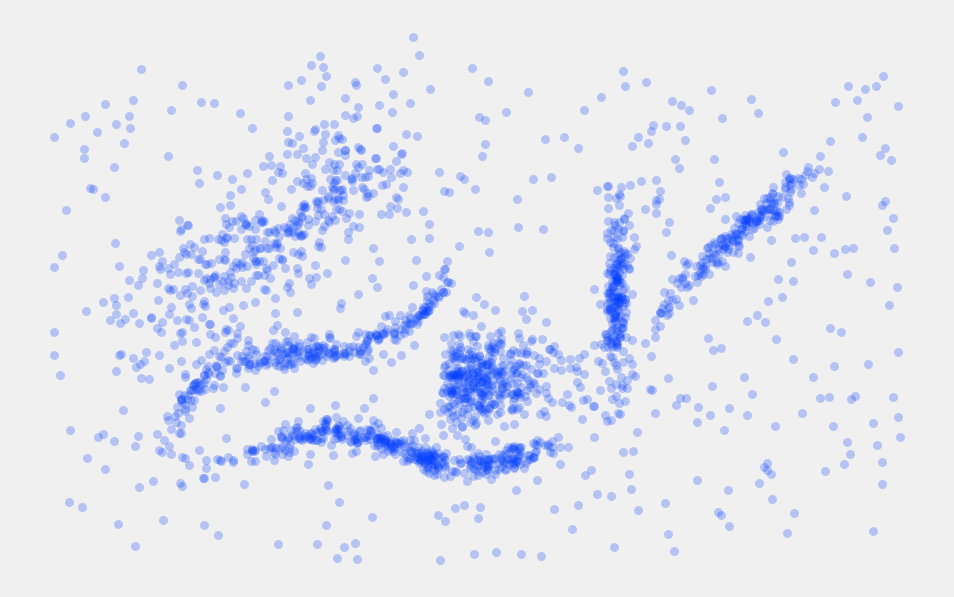

In [13]:
# Visualizing the data
plt.scatter(data.T[0], data.T[1], c='b', **plot_kwds)
frame = plt.gca()
frame.axes.get_xaxis().set_visible(False)
frame.axes.get_yaxis().set_visible(False)

Dengan melihat visualisasi diatas, kita sudah bisa mengidentifikasi beberapa clusters, walaupun data tersebut cukup noisy di beberapa bagian. Dan bisa kita perhatikan, bahwa beberapa clusters mempunyai bentuk yang memanjang dan memberikan batasan yang jelas adalah hal yang cukup sulit dilakukan, namun, kita bisa menggunakan beberapa algoritma dan kita bisa melihat bagaimana algoritma tersebut membuat cluster pada data. 

## Testing the Algorithms

Dalam pemrograman, ada baiknya kita mengikuti prinsip DRY (Don't Repeat yourself). Oleh karena itu, kita bisa menghindari untuk melakukan koding yang serupa dan berulang-ulang, dengan cara membuat utility function yang mengambil algoritma clustering, menjalankannya, dan juga melakukan visualisasi sekaligus.

In [14]:
# defining a utility function for testing the clustering algorithms
def plot_clusters(data, algorithm, args, kwds):
    # cluster the data while taking the time the process needs 
    start_time = time.time()
    labels = algorithm(*args, **kwds).fit_predict(data)
    end_time = time.time()
    
    # defining the colors for visual representation
    palette = sns.color_palette('bright', np.unique(labels).max() + 1)
    colors = [palette[x] if x >= 0 else (0.0, 0.0, 0.0) for x in labels]
    
    # plotting the data, removing the axis and adding title and time 
    plt.scatter(data.T[0], data.T[1], c=colors, **plot_kwds)
    frame = plt.gca()
    frame.axes.get_xaxis().set_visible(False)
    frame.axes.get_yaxis().set_visible(False)
    plt.title('Clusters found by {}'.format(str(algorithm.__name__)), fontsize=24)
    plt.text(-0.5, 0.7, 'Clustering took {:.2f} s'.format(end_time - start_time), fontsize=14)

## K-Means

K-Means mungkin adalah algoritma untuk clustering yang cukup umum digunakan. Algoritma ini cukup cepat, dan cukup mudah di mengerti. Kamu akan menemukan implementasi K-Means untuk most case dari statistical/machine learning tools.


### How does it work?

Tujuan dari K-Means cukup simple: iaitu melakukan grouping pada data points yang serupa/similar dengan menggunakan jumlah cluster yang sudah fix, berupa parameter (*k*). Pada kasus ini, bisa juga dilihat sebagai jumlah dari centroids. Dengan centroid, dia menjadi representasi dari pusat cluster secara sementara/imaginer ataupun secara real.

Algoritma dari k-means bertujuan untuk memilih centroids yang meminimalisir dari **inertia**, atau **within-cluster sum of squared criterion**:

$$\sum_{i=0}^{n}\min_{\mu_j \in C}(||x_j - \mu_i||^2)$$

K-Means dimulai dari initial estimations untuk mencari lokasi dari centroid. Selanjutnya algoritma akan melakukan iterasi dengan 2 steps:

#### 1. Data assignment

Setiap centroid mendifinisikan satu cluster. Pada step ini, setiap data point akan diassign pada centroid yang terdekat, berdasarkan dari squared Euclidean distance. Secara formal, jika $c_i$ adalah bagian dari kumpulan centroids pada set $C$, maka setiap data point $x$ akan diassign pada cluster berdasarkan:

$$\underset{c_i \in C}{\arg\min} \; dist(c_i,x)^2$$

Dimana dist( · ) adalah standard ($L_2$) Euclidean distance. Kemudian kumpulan / set dari data points akan diassgin pada ith cluster centroid dengan notasi $S_i$.


#### 2. Centroid update       

Pada step ini, centroids akan dihitung ulang (recomputed) dengan cara, mengambil nilai rata2 dari semua data points yang diassign pada centroid's cluster tersebut.

$$c_i=\frac{1}{|S_i|}\sum_{x_i \in S_i x_i}$$

Perbedaan dari centroids yang baru dengan yang lama akan dihitung dan algoritma akan melakukan repetisi pada 2 langkah utama ini, sampai memenuhi stopping criteria (contohnya, nilai lebih kecil dari threshold, tidak ada data point yang merubah clusters, atau jumlah dari jarak sudah diminimalisir dan jumlah maksimum dari iterasi sudah terpenuhi.


#### Convergence and random initialization

Dengan melakukan beberapa iterasi, algoritma k-means akan converge / memberikan hasil. Namun hasil tersebut bisa jadi adalah local minimum (i.e. tidak berarti akan mendapatkan hasil yang terbaik). Yang berarti, jika kita ingin mendapatkan hasil yang lebih baik, kita bisa melakukan experiment dalam mengubah nilai starting centroid secara random kembali dan melakukan iterasi yang berbeda.


<img src=https://upload.wikimedia.org/wikipedia/commons/e/ea/K-means_convergence.gif style="width: 500px;" />

### Pros and Cons

#### Limitations

* Inertia/sum of squared criterion memberikan assumsi pada clusters berupa convex/cembung dan isotropic/serupa, dimana tidak selalu seperti itu. Jadi algoritma tersebut mempunyai kesulitan untuk menidentifikasi clusters yang panjang yang bisa berbentuk cekung atau bahkan dengan bentuk yang tidak beraturan
* kita perlu melakukan spesifikasi berapa banyak cluster yang diharapkan. Jika kita tidak tau berapa banyak cluster yang reasonable, kita perlu menjalankan algoritma beberapa kali dengan hyperparameter *k* yang berbeda-beda.

#### Advantages

* K-Means bisa menjadi algoritma yang efficient dan cepat untuk dijalankan. Jika kita mempunyai data yang sangat banyak, K-Means bisa jadi algoritma yang tepat untuk digunakan.

Mari kita lihat bagaimana algoritma K-Means perform pada dataset yang disediakan.

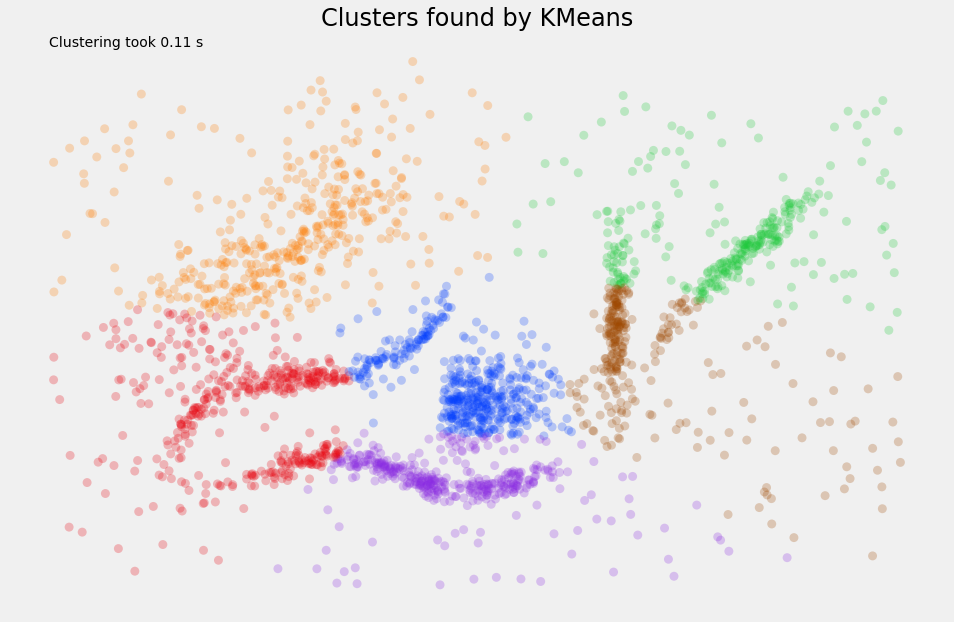

In [15]:
plot_clusters(data, cluster.KMeans, (), {'n_clusters':6})

Dengan keterbatasan dari K-Means, kita bisa lihat hasil diatas bahwa beberapa cluster yang dihasilkan tidak sesuai harapan. Dikarenakan K-Means memberikan asumsi bahwa set dari data points berbentuk globular (berbentuk kurang lebih bulat dengan central graviti ditengah), cluster yang berbentuk panjang diidentifikasi secara tidak baik. Bahkan, yang lebih buruk, data points yang bersifat noise/acak dimasukkan kedalam clusters juga.

Dilain sisi, seperti yang sudah dijelaskan diatas, keuntungan menggunakan K-Means adalah dia adalah algoritma yang sangat cepat untuk melakukan clustering pada data.

Untuk mempelajari K-Means lebih lanjut dan bagaimana K-Means perform pada different data, bisa dilihat di: [website](https://www.naftaliharris.com/blog/visualizing-k-means-clustering/) by Naftali Harris. Kita bisa memilih dataset yang berbeda dan juga menggunakan centroids yang berbeda.

## Hierarchical Clustering

Teknik algoritma clustering yang lain yang sering digunakan adalah hierarchical clustering. Algoritma ini berasal dari idea untuk melakukan clustering dengan cara merging dan splitting data. Ada dua jenis clustering pada algoritma ini:


#### 1. Divisive clustering

Pada metode ini, kita melakukan assignments pada data points kita kepada single cluster dan kemudian, kita melakukan partisi menjadi setidaknya 2 partisi yang mempunyai kemiripan. Kemudian, kita lakukan step secara rekursif sampai setidaknya ada satu cluster pada setiap observasi.


#### 2. Agglomerative clustering

Ini adalah jenis utama pada hierarchical clustering, yang biasa disebut dengan *agglomerative* algorithm, yang dimana dia melakukan clustering dengan cara merging / bottom-up approach. Setiap observasi diawali dengan cluster sendiri. Selanjutnya kita akan menghitung similarity (e.g. distance) diantara setiap cluster, dan dua cluster yang mempunyai kemiripan akan digabung. Pada akhirnya, dengan iterasi/perhitungan secara repetitif, kita akan mendapatkan satu cluster yang sangat besar dari hierarchy.

Kita bisa mengatur hyperparameter dengan beberap merge strategy salah satunya dengan **Ward**.

* **Ward**: meminimalisir sum of squared dari perbedaan yang ada pada cluster
* **Maximum** atau **complete linkage**: meminimalisir jarak maximum antara observation dari beberapa clusters.
* **Single linkage**: meminimalisir jarak antara observasi yang terdekat dari beberapa clusters.

#### Dendrogram 

Dendrograms adalah tree diagram yang sering kali digunakan untuk membuat ilustrasi clusters yang dihasilkan oleh hierarchical clustering. Clade/Grouping dilakukan dengan cara mencari persamaan dan ketidaksamaan dari data points.
Clade yang mempunyai tinggi yang hampir sama adalah serupa dengan yang lain; jika clade memiliki tinggi yang berbeda maka bisa kita anggap bahwa data points tersebut tidak sama. The greater the difference, the greater the dissimilarity.

Contoh yang melibatkan iris dataset bisa dilihat pada gambar berikut:

<img src=https://upload.wikimedia.org/wikipedia/commons/1/12/Iris_dendrogram.png height='600px' width = '600px'>

### Pros and Cons

#### Limitations

* Mirip seperti K-Means, Algoritma ini masih mengasumsikan bahwa semua data points itu milik dari cluster, jadi dia tidak robus terhadap noise.
* kita perlu memberikan spesifikasi berapa jumlah cluster yang kita inginkan (`n_cluster`), pada kasus sesungguhnya, memilih jumlah kluster secara tepat berapa banyak, adalah mustahil jika kita tidak mengatahui berapa jumlah labelnya.

#### Advantages

* Tidak ada asumsi bentuk globular, maka cluster bisa berkembang dengan bentuk yang lebih beragam (contohnya memanjang)
* hierarchy pada cluster bisa divisualisasikan menggunakan dendogram dengan tujuan untuk mendapatkan informasi lebih bagaimana data points diassign terhadap cluster.
* Performa algoritma bisa jadi lebih bagus dari K-Means dengan implementasi yang tepat. Algoritma pada `sklearn` agak cukup lambat, tetapi kita bisa menggunakan library dari project fastcluster [fastcluster](https://pypi.python.org/pypi/fastcluster) yang menyediakan agglomerative clustering yang memiliki performa yang tinggi.
* Dikarenakan kita tidak memulai secara random, maka algoritma ini cenderung lebih stabil. 

Mari kita lihat bagaimana `AgglomerativeClustering` bekerja pada data. Kita akan memberikan 4 buah cluster dan memilih `ward` untuk linkage/merge method yang lebih robust dalam memilah noise yang berada diantara clusters.

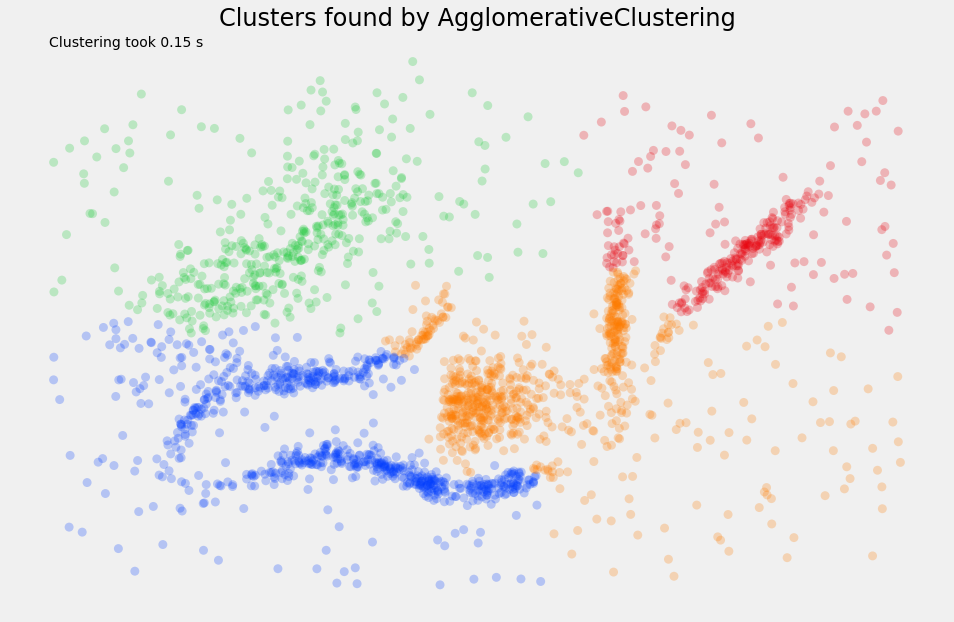

In [16]:
plot_clusters(data, cluster.AgglomerativeClustering, (), {'n_clusters':4, 'linkage':'ward'})

Bisa kita lihat, hasil yang diberikan oleh `AgglomerativeClustering` lebih baik dari pada K-Means, tetapi bisa kita lihat masih ada beberapa clusters yang memiliki data points yang seharusnya secara natural dimiliki oleh cluster yang lain. Meskipun demikian, data points yang misclassified sekarang lebih sedikit.

Sama seperti K-Means, data noise yang berada pada sekitar cluster juga ikut dimasukkan kedalam cluster. Karena algoritma ini tidak bisa mengidentifikasi noise. Dan sama juga seperti K-Means, algoritma ini cukup cepat dalam melakukan clustering.

### Dendrogram 

Kita bisa plot dendogram pada data kita. Vertical axis dari dendrogram merepresentasikan jarak / dissimilarity antara cluster. Setiap fusion dari dua cluster direpresantasikan dengan menggabungkan dua vertical line yang terpisah dengan satu vertical line diatasnya dan garis horizontal menjadi penghubung dan memberikan jarak dissimilarity pada dua clusters.

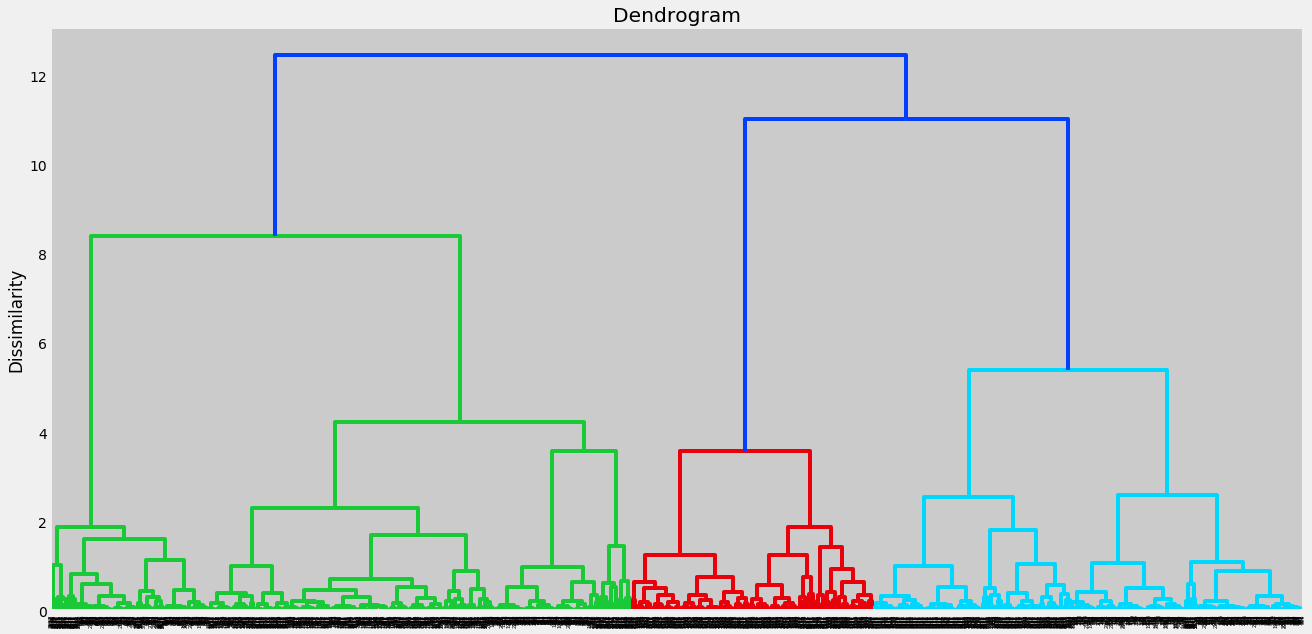

In [17]:
# Plotting the dendrogram of our data
plt.figure(figsize=(20, 10))
plt.title('Dendrogram')
plt.ylabel('Dissimilarity')
plt.grid(True)
dendrogram = sch.dendrogram(sch.linkage(data, method = 'ward'))
plt.show()

## DBSCAN

DBSCAN adalah algoritma yang berdasarkan density / kepadatan. Algoritma ini akan melakukan clustering berdasarkan pada area yang memiliki kepadatan yang cukup tinggi dipisahkan dengan area yang mempunyai kepadatan yang rendah.
Algoritma ini tidak melakukan assignment untuk setiap data point kepada cluster, tetapi benar-benar mengekstrak *kepadatan* dari clusters dan mengabaikan data points yang sifatnya noise.

Dikarenakan algoritma ini langsung mengekstrak kepadatan, maka cluster yang ditemukan oleh DBSCAN bisa mempunyai bentuk apapun, berbeda dengan K-Means yang berasumsi clusters mempunyai bentuk yang convex/cembung. Komponen utama dari DBSCAN adalah data pada area yang memiliki high density dimana data points dikelompokkan pada data yang mempunyai jarak yang paling dekat satu sama lain (di ukur dengan ukuran distance).

Hyperparameter yang paling penting kita gunakan adalah `eps` atau epsilon. Dengan epsilon yang tidak tepat, kita bisa mendapatkan hasil yang kurang sempurnya. Dengan `eps` kita bisa mengatur jarak maksimum antara samples yang bisa dianggap sebagai tetangga. Untuk melihat visualisasi dari efek epsilon terhadap performa clustering, bisa dilihat di website berikut: 
[awesome website](https://www.naftaliharris.com/blog/visualizing-dbscan-clustering/) and coba dengan beberapa nilai yang berbeda. 


![dbscan](https://3.bp.blogspot.com/-rDYuyg00Z0w/WXA-OQpkAfI/AAAAAAAAI_I/QshfNVNHD_wXJwXEipRIVzDSX5iOEAy2wCEwYBhgL/s1600/DBSCAN_Points.PNG)


### Pros and Cons

#### Limitations

* Clusters yang mempunyai density yang sangat beragam akan mempengaruhi performa.
  

#### Advantages

* Clusters tidak harus berbentuk globular.
* Noise tidak akan diassign kedalam cluster.
* Cukup stabil dalam implementasi dan menghasilkan hasil yang lebih diharapkan.
* Cukup cepat dan mampu untuk melakukan cluster terhadap datasets yang sangat besar.

Mari kita lihat bagaimana DBSCAN bekerja pada data dan kita pilih `eps` dengan nilai 0.025. (kita harus melakukan experiment untuk mendapatkan epsilon yang tepat)

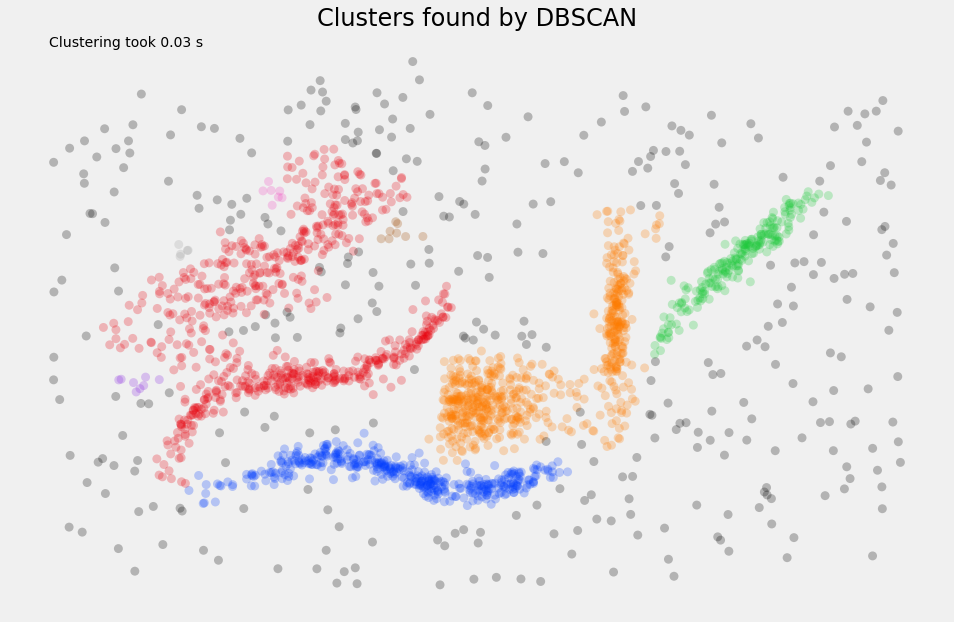

In [18]:
plot_clusters(data, cluster.DBSCAN, (), {'eps':0.025})

Bisa kita lihat performa dari DBSCAN cukup baik dalam melakukan clustering. Algoritma ini mampu menidentifikasi beberapa cluster yang natural dan yang mempunyai bentuk yang memanjang. Algoritma inipun tidak menggabungkan noise kedalam clusters. Walaupun algoritma ini tidak terlalu baik dalam melakukan cluster terhadap data yang tersebar luas dan acak, tetapi pada kasus ini, dia sudah melakukan clustering yang memberikan hasil yang cukup baik.